In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import warnings
warnings.filterwarnings('ignore')
!pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable


In [2]:
df = pd.read_excel("C:/Users/Jagdish singh/projects/datasets/flight_price.xlsx")

In [3]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [4]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [5]:
df.isnull().value_counts().sum()

np.int64(10683)

In [6]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [8]:
df.dropna(inplace=True)# axis=0 by defualt
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [9]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [10]:
df.Date_of_Journey

0        24/03/2019
1         1/05/2019
2         9/06/2019
3        12/05/2019
4        01/03/2019
            ...    
10678     9/04/2019
10679    27/04/2019
10680    27/04/2019
10681    01/03/2019
10682     9/05/2019
Name: Date_of_Journey, Length: 10682, dtype: object

In [11]:
df.Date_of_Journey.unique()
df.Date_of_Journey.dtype

df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'])

# Create new columns for day, month, year
df['Day'] = df['Date_of_Journey'].dt.day
df['Month'] = df['Date_of_Journey'].dt.month
df['Year'] = df['Date_of_Journey'].dt.year
#df.drop('Date_of_Journey',inplace=True,axis=1)
df.columns



Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Day', 'Month', 'Year'],
      dtype='object')

In [12]:
df.Date_of_Journey

0       2019-03-24
1       2019-05-01
2       2019-06-09
3       2019-05-12
4       2019-03-01
           ...    
10678   2019-04-09
10679   2019-04-27
10680   2019-04-27
10681   2019-03-01
10682   2019-05-09
Name: Date_of_Journey, Length: 10682, dtype: datetime64[ns]

In [13]:
df.columns
df.Day.dtype
df.Year.astype(int)
df.Month.astype(int)
df.Day.astype(int)

0        24
1         1
2         9
3        12
4         1
         ..
10678     9
10679    27
10680    27
10681     1
10682     9
Name: Day, Length: 10682, dtype: int64

In [14]:
df[['Day','Month','Year']]

,Day,Month,Year
0,24,3,2019
1,1,5,2019
2,9,6,2019
3,12,5,2019
4,1,3,2019
...,...,...,...
10678,9,4,2019
10679,27,4,2019
10680,27,4,2019
10681,1,3,2019


In [15]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Day', 'Month', 'Year'],
      dtype='object')

In [16]:
df.Arrival_Time

0        01:10 22 Mar
1               13:15
2        04:25 10 Jun
3               23:30
4               21:35
             ...     
10678           22:25
10679           23:20
10680           11:20
10681           14:10
10682           19:15
Name: Arrival_Time, Length: 10682, dtype: object

In [17]:
df['Arrival_time_part'] = df['Arrival_Time'].apply(
    lambda x: x.split(' ')[0]
)
df['Arrival_time_part']



0        01:10
1        13:15
2        04:25
3        23:30
4        21:35
         ...  
10678    22:25
10679    23:20
10680    11:20
10681    14:10
10682    19:15
Name: Arrival_time_part, Length: 10682, dtype: object

In [18]:
df['Arrival_date_part'] = df['Arrival_Time'].str.split().str[1:].str.join(' ')
df['Arrival_date_part'] = df['Arrival_date_part'].replace('', None)

df.Arrival_date_part

0        22 Mar
1          None
2        10 Jun
3          None
4          None
          ...  
10678      None
10679      None
10680      None
10681      None
10682      None
Name: Arrival_date_part, Length: 10682, dtype: object

In [19]:
df['Arrival_hour'] = df['Arrival_time_part'].apply(
    lambda x: int(x.split(':')[0])
)
df['Arrival_hour']

0         1
1        13
2         4
3        23
4        21
         ..
10678    22
10679    23
10680    11
10681    14
10682    19
Name: Arrival_hour, Length: 10682, dtype: int64

In [20]:
df['arv_min']=df.Arrival_time_part.str.split(':').str[1].str.join('')
df.arv_min

0        10
1        15
2        25
3        30
4        35
         ..
10678    25
10679    20
10680    20
10681    10
10682    15
Name: arv_min, Length: 10682, dtype: object

In [21]:
df['Arrival_min'] = df['Arrival_time_part'].apply(
    lambda x: int(x.split(':')[1])
)
df['Arrival_min']

0        10
1        15
2        25
3        30
4        35
         ..
10678    25
10679    20
10680    20
10681    10
10682    15
Name: Arrival_min, Length: 10682, dtype: int64

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Airline            10682 non-null  object        
 1   Date_of_Journey    10682 non-null  datetime64[ns]
 2   Source             10682 non-null  object        
 3   Destination        10682 non-null  object        
 4   Route              10682 non-null  object        
 5   Dep_Time           10682 non-null  object        
 6   Arrival_Time       10682 non-null  object        
 7   Duration           10682 non-null  object        
 8   Total_Stops        10682 non-null  object        
 9   Additional_Info    10682 non-null  object        
 10  Price              10682 non-null  int64         
 11  Day                10682 non-null  int32         
 12  Month              10682 non-null  int32         
 13  Year               10682 non-null  int32         
 14  Arrival_tim

In [23]:
df.drop(columns=['Arrival_date_part','Arrival_time_part'],inplace=True,axis=1)

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Dep_Time         10682 non-null  object        
 6   Arrival_Time     10682 non-null  object        
 7   Duration         10682 non-null  object        
 8   Total_Stops      10682 non-null  object        
 9   Additional_Info  10682 non-null  object        
 10  Price            10682 non-null  int64         
 11  Day              10682 non-null  int32         
 12  Month            10682 non-null  int32         
 13  Year             10682 non-null  int32         
 14  Arrival_hour     10682 non-null  int64     

In [25]:
df.Arrival_Time

0        01:10 22 Mar
1               13:15
2        04:25 10 Jun
3               23:30
4               21:35
             ...     
10678           22:25
10679           23:20
10680           11:20
10681           14:10
10682           19:15
Name: Arrival_Time, Length: 10682, dtype: object

In [26]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Day', 'Month', 'Year', 'Arrival_hour',
       'arv_min', 'Arrival_min'],
      dtype='object')

In [27]:
df.Dep_Time

0        22:20
1        05:50
2        09:25
3        18:05
4        16:50
         ...  
10678    19:55
10679    20:45
10680    08:20
10681    11:30
10682    10:55
Name: Dep_Time, Length: 10682, dtype: object

In [28]:

df['dep_hour']= df['Dep_Time'].apply(lambda x:x.split(':')[0])


In [29]:
df['dep_min']= df['Dep_Time'].apply(lambda x:x.split(':')[1])
df.dep_min

0        20
1        50
2        25
3        05
4        50
         ..
10678    55
10679    45
10680    20
10681    30
10682    55
Name: dep_min, Length: 10682, dtype: object

In [30]:
df.drop('Dep_Time',axis=1,inplace=True)

In [31]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Arrival_Time', 'Duration', 'Total_Stops', 'Additional_Info', 'Price',
       'Day', 'Month', 'Year', 'Arrival_hour', 'arv_min', 'Arrival_min',
       'dep_hour', 'dep_min'],
      dtype='object')

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  object        
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  Day              10682 non-null  int32         
 11  Month            10682 non-null  int32         
 12  Year             10682 non-null  int32         
 13  Arrival_hour     10682 non-null  int64         
 14  arv_min          10682 non-null  object    

In [33]:
df['dep_hour']=df['dep_hour'].astype(int)
df['dep_min']=df['dep_min'].astype(int)
df.info()



<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  object        
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  Day              10682 non-null  int32         
 11  Month            10682 non-null  int32         
 12  Year             10682 non-null  int32         
 13  Arrival_hour     10682 non-null  int64         
 14  arv_min          10682 non-null  object    

In [34]:
df.Total_Stops.unique()

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [35]:
df.Total_Stops.isnull().sum()

np.int64(0)

In [36]:
df['Total_Stops'] = df['Total_Stops'].map({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3,
    '4 stops': 4
})



In [37]:
df['Total_Stops'].unique()

array([0, 2, 1, 3, 4])

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  int64         
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  Day              10682 non-null  int32         
 11  Month            10682 non-null  int32         
 12  Year             10682 non-null  int32         
 13  Arrival_hour     10682 non-null  int64         
 14  arv_min          10682 non-null  object    

In [39]:
df[['Source','Destination','Route']]

,Source,Destination,Route
0,Banglore,New Delhi,BLR → DEL
1,Kolkata,Banglore,CCU → IXR → BBI → BLR
2,Delhi,Cochin,DEL → LKO → BOM → COK
3,Kolkata,Banglore,CCU → NAG → BLR
4,Banglore,New Delhi,BLR → NAG → DEL
...,...,...,...
10678,Kolkata,Banglore,CCU → BLR
10679,Kolkata,Banglore,CCU → BLR
10680,Banglore,Delhi,BLR → DEL
10681,Banglore,New Delhi,BLR → DEL


In [40]:
#df.drop('Route',axis=1,inplace=True)



In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  int64         
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  Day              10682 non-null  int32         
 11  Month            10682 non-null  int32         
 12  Year             10682 non-null  int32         
 13  Arrival_hour     10682 non-null  int64         
 14  arv_min          10682 non-null  object    

In [42]:
df.Duration

0        2h 50m
1        7h 25m
2           19h
3        5h 25m
4        4h 45m
          ...  
10678    2h 30m
10679    2h 35m
10680        3h
10681    2h 40m
10682    8h 20m
Name: Duration, Length: 10682, dtype: object

In [43]:
df['dur_hr']=df.Duration.apply(lambda x:x.split(' ')[0])
df.dur_hr

0         2h
1         7h
2        19h
3         5h
4         4h
        ... 
10678     2h
10679     2h
10680     3h
10681     2h
10682     8h
Name: dur_hr, Length: 10682, dtype: object

In [44]:
df['duration_hours'] = df.Duration.str.split(' ').str[0].str.split('h').str[0]
df['duration_hours']

0         2
1         7
2        19
3         5
4         4
         ..
10678     2
10679     2
10680     3
10681     2
10682     8
Name: duration_hours, Length: 10682, dtype: object

In [45]:
df['dur_min'] = df['Duration'].apply(
    lambda x: int(x.split('m')[0].split(' ')[-1]) if 'm' in x else 0
)
df.dur_min


0        50
1        25
2         0
3        25
4        45
         ..
10678    30
10679    35
10680     0
10681    40
10682    20
Name: dur_min, Length: 10682, dtype: int64

In [46]:
df['durtn_hour']=df.Duration.str.split(' ').str[0].str.split('h').str[0]
df['durtn_min']=df.Duration.str.split(' ').str[1].str.split('m').str[0]

In [47]:
df['durtn_min']

0         50
1         25
2        NaN
3         25
4         45
        ... 
10678     30
10679     35
10680    NaN
10681     40
10682     20
Name: durtn_min, Length: 10682, dtype: object

In [48]:
df['duration_min'] = df['Duration'].apply(
    lambda x: int(x.split('m')[0].split(' ')[-1]) if 'm' in x else 0
)


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10682 non-null  object        
 1   Date_of_Journey  10682 non-null  datetime64[ns]
 2   Source           10682 non-null  object        
 3   Destination      10682 non-null  object        
 4   Route            10682 non-null  object        
 5   Arrival_Time     10682 non-null  object        
 6   Duration         10682 non-null  object        
 7   Total_Stops      10682 non-null  int64         
 8   Additional_Info  10682 non-null  object        
 9   Price            10682 non-null  int64         
 10  Day              10682 non-null  int32         
 11  Month            10682 non-null  int32         
 12  Year             10682 non-null  int32         
 13  Arrival_hour     10682 non-null  int64         
 14  arv_min          10682 non-null  object    

In [84]:
df.Additional_Info.unique()
df.Additional_Info.value_counts()
x=df.Additional_Info.value_counts().reset_index(name='count')


In [51]:
df.Additional_Info.value_counts()

Additional_Info
No info                         8344
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [52]:
x

,Additional_Info,count
0,No info,8344
1,In-flight meal not included,1982
2,No check-in baggage included,320
3,1 Long layover,19
4,Change airports,7
5,Business class,4
6,No Info,3
7,1 Short layover,1
8,Red-eye flight,1
9,2 Long layover,1


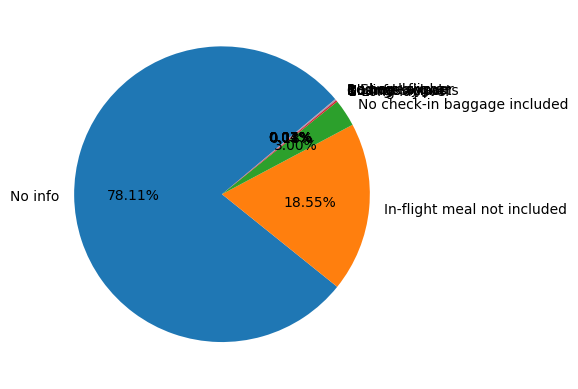

In [ ]:
plt.pie(df.Additional_Info.value_counts(),labels=x.Additional_Info,autopct='%1.2f%%',startangle=40)
plt.show()

In [54]:
df[["Airline","Source","Destination","Additional_Info"]]

,Airline,Source,Destination,Additional_Info
0,IndiGo,Banglore,New Delhi,No info
1,Air India,Kolkata,Banglore,No info
2,Jet Airways,Delhi,Cochin,No info
3,IndiGo,Kolkata,Banglore,No info
4,IndiGo,Banglore,New Delhi,No info
...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,No info
10679,Air India,Kolkata,Banglore,No info
10680,Jet Airways,Banglore,Delhi,No info
10681,Vistara,Banglore,New Delhi,No info


In [91]:
df.Additional_Info.value_counts()

Additional_Info
No info                         8343
In-flight meal not included     1982
No check-in baggage included     320
1 Long layover                    19
Change airports                    7
Business class                     4
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [92]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(
    sparse_output=False,
    handle_unknown='ignore'
)


In [93]:
x=ohe.fit_transform(df[["Airline", "Source", "Destination", "Additional_Info"]])


In [94]:
encodeddf=pd.DataFrame(x)
encodeddf

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10677,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [89]:
feaure_names=ohe.get_feature_names_out()
feaure_names

array(['Airline_Air Asia', 'Airline_Air India', 'Airline_GoAir',
       'Airline_IndiGo', 'Airline_Jet Airways',
       'Airline_Jet Airways Business', 'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Trujet', 'Airline_Vistara',
       'Airline_Vistara Premium economy', 'Source_Banglore',
       'Source_Chennai', 'Source_Delhi', 'Source_Kolkata',
       'Source_Mumbai', 'Destination_Banglore', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad',
       'Destination_Kolkata', 'Destination_New Delhi',
       'Additional_Info_1 Long layover',
       'Additional_Info_1 Short layover',
       'Additional_Info_2 Long layover', 'Additional_Info_Business class',
       'Additional_Info_Change airports',
       'Additional_Info_In-flight meal not included',
       'Additional_Info_No Info',
       'Additional_Info_No check-in baggage included',
       'Additional_Info_No info', 'Additional_Info_Red-eye fli

In [59]:
df[["Airline","Source","Destination","Additional_Info"]]

,Airline,Source,Destination,Additional_Info
0,IndiGo,Banglore,New Delhi,No info
1,Air India,Kolkata,Banglore,No info
2,Jet Airways,Delhi,Cochin,No info
3,IndiGo,Kolkata,Banglore,No info
4,IndiGo,Banglore,New Delhi,No info
...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,No info
10679,Air India,Kolkata,Banglore,No info
10680,Jet Airways,Banglore,Delhi,No info
10681,Vistara,Banglore,New Delhi,No info


In [95]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,Arrival_hour,arv_min,Arrival_min,dep_hour,dep_min,dur_hr,dur_min,durtn_hour,durtn_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,1,10,10,22,20,2,50,2,50
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,13,15,15,5,50,7,25,7,25
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,2019,4,25,25,9,25,19,0,19,NaN
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,2019,23,30,30,18,5,5,25,5,25
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,2019,21,35,35,16,50,4,45,4,45
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0,No info,4107,9,4,2019,22,25,25,19,55,2,30,2,30
10679,Air India,Kolkata,Banglore,CCU → BLR,0,No info,4145,27,4,2019,23,20,20,20,45,2,35,2,35
10680,Jet Airways,Banglore,Delhi,BLR → DEL,0,No info,7229,27,4,2019,11,20,20,8,20,3,0,3,NaN
10681,Vistara,Banglore,New Delhi,BLR → DEL,0,No info,12648,1,3,2019,14,10,10,11,30,2,40,2,40


In [61]:
df = df[df['dur_hr'] != '5m']
df['dur_hr'].unique()

array(['2h', '7h', '19h', '5h', '4h', '15h', '21h', '25h', '13h', '12h',
       '26h', '22h', '23h', '20h', '10h', '6h', '11h', '8h', '16h', '3h',
       '27h', '1h', '14h', '9h', '18h', '17h', '24h', '30h', '28h', '29h',
       '37h', '34h', '38h', '35h', '36h', '47h', '33h', '32h', '31h',
       '42h', '39h', '41h', '40h'], dtype=object)

In [62]:
df.dur_hr=df.dur_hr.apply(lambda x:x.split('h')[0])


In [63]:
df.dur_hr=df.dur_hr.astype(int)

In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 24 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10681 non-null  object        
 1   Date_of_Journey  10681 non-null  datetime64[ns]
 2   Source           10681 non-null  object        
 3   Destination      10681 non-null  object        
 4   Route            10681 non-null  object        
 5   Arrival_Time     10681 non-null  object        
 6   Duration         10681 non-null  object        
 7   Total_Stops      10681 non-null  int64         
 8   Additional_Info  10681 non-null  object        
 9   Price            10681 non-null  int64         
 10  Day              10681 non-null  int32         
 11  Month            10681 non-null  int32         
 12  Year             10681 non-null  int32         
 13  Arrival_hour     10681 non-null  int64         
 14  arv_min          10681 non-null  object    

In [65]:
encodeddf

,0,1,2,3,4,5,6,7,8,9,...,23,24,25,26,27,28,29,30,31,32
0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10680,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
df.drop(columns=['duration_hours','duration_min'],axis=1,inplace=True)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10681 entries, 0 to 10682
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Airline          10681 non-null  object        
 1   Date_of_Journey  10681 non-null  datetime64[ns]
 2   Source           10681 non-null  object        
 3   Destination      10681 non-null  object        
 4   Route            10681 non-null  object        
 5   Arrival_Time     10681 non-null  object        
 6   Duration         10681 non-null  object        
 7   Total_Stops      10681 non-null  int64         
 8   Additional_Info  10681 non-null  object        
 9   Price            10681 non-null  int64         
 10  Day              10681 non-null  int32         
 11  Month            10681 non-null  int32         
 12  Year             10681 non-null  int32         
 13  Arrival_hour     10681 non-null  int64         
 14  arv_min          10681 non-null  object    

In [68]:
df.drop(["Date_of_Journey","Arrival_Time","Duration"],axis=1,inplace=True)

In [69]:
final_df=pd.concat([df,encodeddf],axis=1)

In [70]:
final_df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,...,23,24,25,26,27,28,29,30,31,32
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897.0,24.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662.0,1.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2.0,No info,13882.0,9.0,6.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218.0,12.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302.0,1.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10680,Jet Airways,Banglore,Delhi,BLR → DEL,0.0,No info,7229.0,27.0,4.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10681,Vistara,Banglore,New Delhi,BLR → DEL,0.0,No info,12648.0,1.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10682,Air India,Delhi,Cochin,DEL → GOI → BOM → COK,2.0,No info,11753.0,9.0,5.0,2019.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6474,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [71]:
final_df.dropna(axis=0,inplace=True)

In [72]:
final_df.durtn_hour=final_df.durtn_hour.astype(int)
final_df.durtn_min=final_df.durtn_min.astype(int)

In [73]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9649 entries, 0 to 10681
Data columns (total 52 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Airline          9649 non-null   object 
 1   Source           9649 non-null   object 
 2   Destination      9649 non-null   object 
 3   Route            9649 non-null   object 
 4   Total_Stops      9649 non-null   float64
 5   Additional_Info  9649 non-null   object 
 6   Price            9649 non-null   float64
 7   Day              9649 non-null   float64
 8   Month            9649 non-null   float64
 9   Year             9649 non-null   float64
 10  Arrival_hour     9649 non-null   float64
 11  arv_min          9649 non-null   object 
 12  Arrival_min      9649 non-null   float64
 13  dep_hour         9649 non-null   float64
 14  dep_min          9649 non-null   float64
 15  dur_hr           9649 non-null   float64
 16  dur_min          9649 non-null   float64
 17  durtn_hour       9

In [74]:
x=final_df.drop('Price',axis=1)
y=final_df.Price

In [75]:
x

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Day,Month,Year,Arrival_hour,...,23,24,25,26,27,28,29,30,31,32
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,24.0,3.0,2019.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,1.0,5.0,2019.0,13.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,12.0,5.0,2019.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,1.0,3.0,2019.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,SpiceJet,Kolkata,Banglore,CCU → BLR,0.0,No info,24.0,6.0,2019.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1.0,No info,1.0,5.0,2019.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10677,SpiceJet,Banglore,Delhi,BLR → DEL,0.0,No check-in baggage included,21.0,5.0,2019.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0.0,No info,9.0,4.0,2019.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,Air India,Kolkata,Banglore,CCU → BLR,0.0,No info,27.0,4.0,2019.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [76]:
y

0         3897.0
1         7662.0
3         6218.0
4        13302.0
5         3873.0
          ...   
10676     9794.0
10677     3257.0
10678     4107.0
10679     4145.0
10681    12648.0
Name: Price, Length: 9649, dtype: float64

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2,random_state=42)

In [79]:
x_train

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Day,Month,Year,Arrival_hour,...,23,24,25,26,27,28,29,30,31,32
3898,IndiGo,Chennai,Kolkata,MAA → CCU,0.0,No info,1.0,6.0,2019.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3741,Jet Airways,Kolkata,Banglore,CCU → BOM → BLR,1.0,In-flight meal not included,18.0,5.0,2019.0,16.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,IndiGo,Banglore,Delhi,BLR → DEL,0.0,No info,6.0,4.0,2019.0,6.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7105,Air India,Kolkata,Banglore,CCU → HYD → BLR,1.0,No info,21.0,5.0,2019.0,11.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10260,Air Asia,Banglore,Delhi,BLR → DEL,0.0,No info,18.0,4.0,2019.0,2.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6320,IndiGo,Kolkata,Banglore,CCU → BLR,0.0,No info,9.0,5.0,2019.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5710,Jet Airways,Banglore,New Delhi,BLR → BOM → DEL,1.0,No info,1.0,3.0,2019.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5940,SpiceJet,Mumbai,Hyderabad,BOM → HYD,0.0,No check-in baggage included,6.0,6.0,2019.0,14.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
950,IndiGo,Delhi,Cochin,DEL → HYD → COK,1.0,No info,3.0,3.0,2019.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [80]:
final_df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,...,23,24,25,26,27,28,29,30,31,32
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897.0,24.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662.0,1.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218.0,12.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302.0,1.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,SpiceJet,Kolkata,Banglore,CCU → BLR,0.0,No info,3873.0,24.0,6.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1.0,No info,9794.0,1.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10677,SpiceJet,Banglore,Delhi,BLR → DEL,0.0,No check-in baggage included,3257.0,21.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0.0,No info,4107.0,9.0,4.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,Air India,Kolkata,Banglore,CCU → BLR,0.0,No info,4145.0,27.0,4.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
x_train 
x_test


,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Day,Month,Year,Arrival_hour,...,23,24,25,26,27,28,29,30,31,32
3303,Jet Airways,Kolkata,Banglore,CCU → BOM → BLR,1.0,No info,9.0,6.0,2019.0,12.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
8917,IndiGo,Delhi,Cochin,DEL → BLR → COK,1.0,No info,24.0,4.0,2019.0,22.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4414,Air India,Delhi,Cochin,DEL → JAI → BOM → COK,2.0,No info,12.0,6.0,2019.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2641,Air India,Delhi,Cochin,DEL → NAG → BOM → COK,2.0,No info,9.0,4.0,2019.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3617,Vistara,Kolkata,Banglore,CCU → DEL → BLR,1.0,No info,9.0,6.0,2019.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3938,Vistara,Banglore,Delhi,BLR → DEL,0.0,No info,6.0,5.0,2019.0,19.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10386,Air India,Kolkata,Banglore,CCU → BLR,0.0,No info,27.0,5.0,2019.0,23.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
5157,Vistara,Delhi,Cochin,DEL → COK,0.0,No info,27.0,5.0,2019.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7072,IndiGo,Chennai,Kolkata,MAA → CCU,0.0,No info,1.0,5.0,2019.0,21.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
'''# Convert all column names to strings
x_train.columns = x_train.columns.astype(str)
x_test.columns = x_test.columns.astype(str)
final_df.columns=final_df.columns.astype(str)

# Now your scaling code will work
from sklearn.preprocessing import StandardScaler
std = StandardScaler()
x_train_scaled = std.fit_transform(x_train)
x_test_scaled = std.transform(x_test)
final_df_scaled=std.fit_transform(final_df)
this will show error becuase all data is miexed of num+category
'''

In [ ]:
x_train_scaled = std.fit_transform(x_train)

In [ ]:
x_test_scaled = std.transform(x_test)

In [ ]:
final_df_scaled=pd.DataFrame(final_df_scaled)
final_df_scaled

In [ ]:
x_test_scaled=pd.DataFrame(x_test_scaled)
x_test_scaled

In [ ]:
x_train

,Total_Stops,Day,Month,Year,Arrival_hour,Arrival_min,dep_hour,dep_min,dur_hr,dur_min,...,23,24,25,26,27,28,29,30,31,32
3898,0.0,1.0,6.0,2019.0,0.0,25.0,22.0,5.0,2.0,20.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3741,1.0,18.0,5.0,2019.0,16.0,20.0,20.0,0.0,20.0,20.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
32,0.0,6.0,4.0,2019.0,6.0,50.0,4.0,0.0,2.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7105,1.0,21.0,5.0,2019.0,11.0,5.0,19.0,0.0,16.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10260,0.0,18.0,4.0,2019.0,2.0,45.0,23.0,55.0,2.0,50.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6320,0.0,9.0,5.0,2019.0,0.0,50.0,22.0,15.0,2.0,35.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5710,1.0,1.0,3.0,2019.0,0.0,45.0,8.0,55.0,15.0,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5940,0.0,6.0,6.0,2019.0,14.0,45.0,13.0,15.0,1.0,30.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
950,1.0,3.0,3.0,2019.0,22.0,20.0,6.0,40.0,15.0,40.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
print([type(col) for col in x_train.columns])

[<class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>, <class 'str'>]


In [104]:
final_df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,Day,Month,Year,...,23,24,25,26,27,28,29,30,31,32
0,IndiGo,Banglore,New Delhi,BLR → DEL,0.0,No info,3897.0,24.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2.0,No info,7662.0,1.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1.0,No info,6218.0,12.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1.0,No info,13302.0,1.0,3.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,SpiceJet,Kolkata,Banglore,CCU → BLR,0.0,No info,3873.0,24.0,6.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,Multiple carriers,Delhi,Cochin,DEL → BOM → COK,1.0,No info,9794.0,1.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10677,SpiceJet,Banglore,Delhi,BLR → DEL,0.0,No check-in baggage included,3257.0,21.0,5.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0.0,No info,4107.0,9.0,4.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,Air India,Kolkata,Banglore,CCU → BLR,0.0,No info,4145.0,27.0,4.0,2019.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
from sklearn.compose import ColumnTransformer



In [ ]:
final_df

,Total_Stops,Price,Day,Month,Year,Arrival_hour,Arrival_min,dep_hour,dep_min,dur_hr,...,23,24,25,26,27,28,29,30,31,32
0,0.0,3897.0,24.0,3.0,2019.0,1.0,10.0,22.0,20.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,2.0,7662.0,1.0,5.0,2019.0,13.0,15.0,5.0,50.0,7.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
3,1.0,6218.0,12.0,5.0,2019.0,23.0,30.0,18.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,1.0,13302.0,1.0,3.0,2019.0,21.0,35.0,16.0,50.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5,0.0,3873.0,24.0,6.0,2019.0,11.0,25.0,9.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10676,1.0,9794.0,1.0,5.0,2019.0,19.0,0.0,10.0,20.0,8.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
10677,0.0,3257.0,21.0,5.0,2019.0,8.0,35.0,5.0,55.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10678,0.0,4107.0,9.0,4.0,2019.0,22.0,25.0,19.0,55.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10679,0.0,4145.0,27.0,4.0,2019.0,23.0,20.0,20.0,45.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [105]:
x=final_df.select_dtypes(exclude='object')
x.columns

Index(['Total_Stops', 'Price', 'Day', 'Month', 'Year', 'Arrival_hour',
       'Arrival_min', 'dep_hour', 'dep_min', 'dur_hr', 'dur_min', 'durtn_hour',
       'durtn_min', '0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10',
       '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22',
       '23', '24', '25', '26', '27', '28', '29', '30', '31', '32'],
      dtype='object')

In [108]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
# Separate columns
num_cols = final_df.select_dtypes(exclude='object').columns
cat_cols = final_df.select_dtypes(include='object').columns


processor = ColumnTransformer(
    transformers=[
        ('num_scaler', StandardScaler(), num_cols),
        ('cat_encoder', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)



In [ ]:
FINALDF_scaled = processor.fit_transform(final_df)
FINALDF_scaled=pd.DataFrame(FINALDF_scaled)
FINALDF_scaled

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
0,-1.204995,-1.094616,1.244192,-1.442645,0.0,-1.759372,-0.953873,1.629257,-0.273334,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
1,1.750145,-0.286762,-1.470557,0.268385,0.0,-0.016303,-0.644809,-1.283983,1.329298,-0.366752,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
2,0.272575,-0.596600,-0.172199,0.268385,0.0,1.436254,0.282382,0.943789,-1.074650,-0.601778,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
3,0.272575,0.923409,-1.470557,-1.442645,0.0,1.145742,0.591446,0.601055,1.329298,-0.719291,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
4,-1.204995,-1.099765,1.244192,1.123899,0.0,-0.306815,-0.026682,-0.598515,-1.341755,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9644,0.272575,0.170700,-1.470557,0.268385,0.0,0.855231,-1.572000,-0.427148,-0.273334,-0.249239,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,5.434594,-1.885090,-0.010181
9645,-1.204995,-1.231940,0.890094,0.268385,0.0,-0.742582,0.591446,-1.283983,1.596403,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
9646,-1.204995,-1.049556,-0.526296,-0.587130,0.0,1.290998,-0.026682,1.115156,1.596403,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
9647,-1.204995,-1.041402,1.598290,-0.587130,0.0,1.436254,-0.335745,1.286523,1.062193,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181


In [ ]:
final_df_scaled

,0,1,2,3,4,5,6,7,8,9,...,36,37,38,39,40,41,42,43,44,45
0,-1.204995,-1.094616,1.244192,-1.442645,0.0,-1.759372,-0.953873,1.629257,-0.273334,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
1,1.750145,-0.286762,-1.470557,0.268385,0.0,-0.016303,-0.644809,-1.283983,1.329298,-0.366752,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
2,0.272575,-0.596600,-0.172199,0.268385,0.0,1.436254,0.282382,0.943789,-1.074650,-0.601778,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
3,0.272575,0.923409,-1.470557,-1.442645,0.0,1.145742,0.591446,0.601055,1.329298,-0.719291,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
4,-1.204995,-1.099765,1.244192,1.123899,0.0,-0.306815,-0.026682,-0.598515,-1.341755,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9644,0.272575,0.170700,-1.470557,0.268385,0.0,0.855231,-1.572000,-0.427148,-0.273334,-0.249239,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,5.434594,-1.885090,-0.010181
9645,-1.204995,-1.231940,0.890094,0.268385,0.0,-0.742582,0.591446,-1.283983,1.596403,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
9646,-1.204995,-1.049556,-0.526296,-0.587130,0.0,1.290998,-0.026682,1.115156,1.596403,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
9647,-1.204995,-1.041402,1.598290,-0.587130,0.0,1.436254,-0.335745,1.286523,1.062193,-0.954317,...,-0.042011,-0.010181,-0.010181,-0.020365,-0.024944,-0.47397,-0.017635,-0.184006,0.530479,-0.010181
